# Image Segmentation

Author: Hasith Wijesuriya 

Email: hasitha.wijesuriya@pnnl.gov

## Why Image Segmentation?

Image segmentation is a fundamental task in computer vision that involves partitioning an image into meaningful regions or segments. It is crucial for various applications, including object recognition, medical imaging, autonomous driving, and scene understanding. By segmenting an image, we can identify and analyze specific objects or areas of interest, which can lead to better decision-making and improved performance in downstream tasks.

### Why is it important in soil science?

In soil science, image segmentation plays a vital role in analyzing soil properties and understanding soil structure. It allows researchers to identify and quantify different soil components, such as organic matter, minerals, and pore spaces. This information is essential for studying soil health, fertility, and water retention capabilities. Additionally, image segmentation can help in monitoring soil erosion, assessing land degradation, and optimizing agricultural practices by providing insights into soil composition and structure.

## Types of Image Segmentation

There are several types of image segmentation techniques, each with its own advantages and applications. Some common types include:

1. **Thresholding**: This technique involves separating pixels based on their intensity values. It is simple and effective for images with distinct foreground and background regions.
2. **Edge-based Segmentation**: This method detects edges in an image to define segment boundaries. It is useful for images with clear edges and can be implemented using techniques like Canny edge detection.
3. **Region-based Segmentation**: This approach groups pixels into regions based on similarity criteria, such as color or texture. It can be implemented using methods like region growing or watershed segmentation.
4. **Clustering-based Segmentation**: This technique uses clustering algorithms, such as K-means or mean shift, to group pixels into clusters based on their features. It is effective for images with complex patterns and textures.
5. **Deep Learning-based Segmentation**: This method utilizes convolutional neural networks (CNNs) to learn features and perform segmentation. It has shown significant improvements in accuracy and is widely used in various applications, including medical imaging and autonomous driving.

## Challenges in Image Segmentation

Despite its importance, image segmentation faces several challenges, including:
1. **Variability in Image Quality**: Images can vary in quality due to factors like contrast, noise, and resolution, which can affect segmentation accuracy.
2. **Complexity of Scenes**: Real-world images often contain complex scenes with multiple objects and varying backgrounds, making segmentation more difficult.
3. **Computational Complexity**: Some segmentation techniques, especially deep learning-based methods, can be computationally intensive and require significant resources for training and inference.
4. **Lack of Annotated Data**: For supervised learning-based segmentation methods, obtaining annotated data can be time-consuming and expensive, especially in specialized domains like soil science.
5. **Generalization**: Segmentation models may struggle to generalize well to new images or different domains, leading to reduced performance when applied to unseen data.



## Thresholding Methods

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from ipywidgets import interact, IntSlider

import os
import sys
from skimage.filters import threshold_otsu, threshold_niblack, threshold_sauvola

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# reading a 8-bit grayscale image
img = mpimg.imread("./Images/Bean Bucket 8bit image0000.tif")

def update_threshold(thresh_val):
    '''
    Update the binary image based on the threshold value and display both original and binary images.
    Parameters:
    thresh_val (int): The threshold value to convert the grayscale image to binary.
    '''
    binary_img = img > thresh_val
    plt.figure(figsize=(18, 6))
    
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.hist(img.ravel(), bins=255)
    plt.axvline(thresh_val, color='r', linestyle='--', label=f'Threshold: {thresh_val}')
    plt.title('Image Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.subplot(1, 3, 3)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f'Binary Image (Threshold: {thresh_val})')
    plt.axis('off')
    

    plt.tight_layout()
    plt.show()


interact(update_threshold, thresh_val=IntSlider(min=0, max=255, step=1, value=127, description='Threshold Value:'));

interactive(children=(IntSlider(value=127, description='Threshold Value:', max=255), Output()), _dom_classes=(…

### Otsu's method
Otsu's method is a global thresholding technique that automatically determines the optimal threshold value by maximizing the between-class variance. It is effective for images with bimodal histograms, where the foreground and background are well separated.

$\sigma^2_\omega (t) = \omega_1 (t) \sigma^2_1 (t) + \omega_2 (t) \sigma^2_2 (t)$

Where:
- $\omega_1 (t)$ and $\omega_2 (t)$ are the probabilities of the two classes separated by the threshold t.
- $\sigma^2_1 (t)$ and $\sigma^2_2 (t)$ are the variances of the two classes.



### Niblack's method

Calculates the threshold for each pixel based on the mean and standard deviation of a local neighborhood around the pixel. It is effective for images with varying contrast.

$T(x,y) = m(x,y) + k \cdot s(x,y)$

Where:
- $T(x,y)$ is the threshold for the pixel at coordinates (x, y).
- $m(x,y)$ is the mean of the local neighborhood around the pixel.
- $s(x,y)$ is the standard deviation of the local neighborhood around the pixel.
- $k$ is a user-defined parameter that controls the influence of the standard deviation on the threshold.


### Sauvola's method

Calculates the threshold for each pixel based on the mean and standard deviation of a local neighborhood, similar to Niblack's method, but includes a parameter to control the influence of the standard deviation. It is effective for images with varying contrast and noise.

$T(x,y) = m(x,y) \cdot \left(1 + k \cdot \left(\frac{s(x,y)}{R} - 1\right)\right)$

Where:
- $T(x,y)$ is the threshold for the pixel at coordinates (x, y).
- $m(x,y)$ is the mean of the local neighborhood around the pixel.
- $s(x,y)$ is the standard deviation of the local neighborhood around the pixel.
- $k$ is a user-defined parameter that controls the influence of the standard deviation on the threshold.
- $R$ is the dynamic range of the standard deviation (typically set to 128 for 8-bit images).


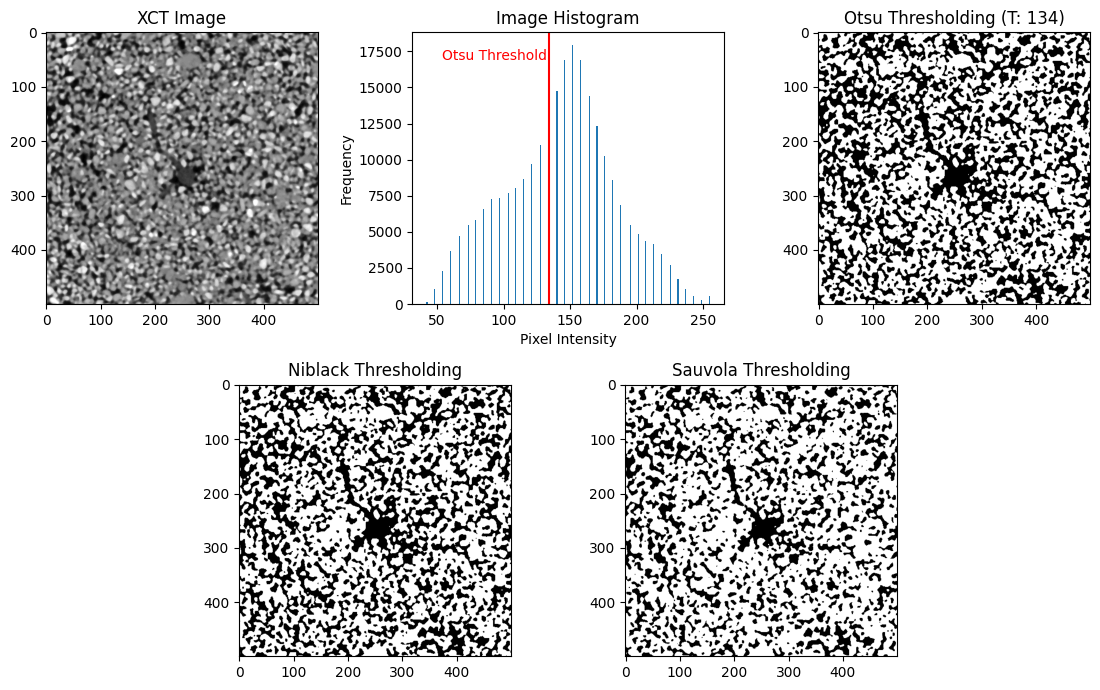

In [15]:
# Load the 8-bit grayscale image
img = mpimg.imread("./Images/Bean Bucket 8bit image0000.tif")

# Apply different thresholding methods #
# Otsu's method, Niblack's method, and Sauvola's method are applied to the image to compute the respective thresholds.
thresh_otsu = threshold_otsu(img)
thresh_niblack = threshold_niblack(img, window_size=301, k=0.2)
thresh_sauvola = threshold_sauvola(img, window_size=301)

# The resulting binary images are created by comparing the original image to the computed thresholds, 
# resulting in binary images where pixels above the threshold are set to True (or 1) and those below are set to False (or 0).
binary_niblack = img > thresh_niblack
binary_otsu = img > thresh_otsu
binary_sauvola = img > thresh_sauvola


# Visualization of the original image, histogram, and the results of the three thresholding methods.
fig = plt.figure(figsize=(15, 7), tight_layout=True)
spec = gridspec.GridSpec(ncols=8, nrows=2, figure=fig)

positions = [
    (0, slice(1, 3)), (0, slice(3, 5)), (0, slice(5, 7)), # Row 0
    (1, slice(2, 4)), (1, slice(4, 6))                   # Row 1 (centered)
]

ax = [fig.add_subplot(spec[row, col]) for row, col in positions]


ax[0].imshow(img, cmap="gray")
ax[0].set_title("XCT Image")
ax[1].hist(img.ravel(), bins=255)
ax[1].axvline(thresh_otsu, color='r')
ax[1].text(thresh_otsu -80, ax[1].get_ylim()[1] * 0.9, 'Otsu Threshold', color='r')
ax[1].set_title("Image Histogram")
ax[1].set_xlabel("Pixel Intensity")
ax[1].set_ylabel("Frequency")
ax[2].imshow(binary_otsu, cmap="gray")
ax[2].set_title(f"Otsu Thresholding (T: {thresh_otsu})")
ax[3].imshow(binary_niblack, cmap="gray")
ax[3].set_title("Niblack Thresholding")
ax[4].imshow(binary_sauvola, cmap="gray")
ax[4].set_title("Sauvola Thresholding")

plt.subplots_adjust()
plt.show()